In [1]:
include("PlotSetup.jl")

@R_str (macro with 1 method)

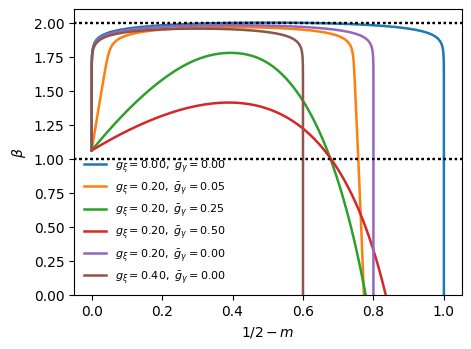

(outfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/code/../data/nt_ndelta_trajectories.pdf", logN = 23.02585092994046, parameter_sets = [(g_xi = 0.0, bar_g_gamma = 0.0), (g_xi = 0.2, bar_g_gamma = 0.05), (g_xi = 0.2, bar_g_gamma = 0.25), (g_xi = 0.2, bar_g_gamma = 0.5), (g_xi = 0.2, bar_g_gamma = 0.0), (g_xi = 0.4, bar_g_gamma = 0.0)], summaries = NamedTuple[(g_xi = 0.0, bar_g_gamma = 0.0, peak_tau = 23.028729521130604, peak_Ifrak = 0.24999948220617768, peak_n_t = 0.4992803516978187, peak_n_delta = 0.5007196485021822), (g_xi = 0.2, bar_g_gamma = 0.05, peak_tau = 30.225207496483915, peak_Ifrak = 0.11553416811766024, peak_n_t = 0.4657316751590503, peak_n_delta = 0.24807023932440192), (g_xi = 0.2, bar_g_gamma = 0.25, peak_tau = 44.186374768669346, peak_Ifrak = 0.0014901291392631635, peak_n_t = 0.21734364237785975, peak_n_delta = 0.0068560972060665165), (g_xi = 0.2, bar_g_gamma = 0.5, peak_tau = 22.74087040211647, peak_Ifrak = 3.328300116487239e-7,

In [2]:
using DifferentialEquations

_plot_cache_dir = mktempdir()
ENV["MPLCONFIGDIR"] = get(ENV, "MPLCONFIGDIR", _plot_cache_dir)
ENV["XDG_CACHE_HOME"] = get(ENV, "XDG_CACHE_HOME", _plot_cache_dir)

using PyPlot
using Printf

"""
    meanfield_bar_gamma!(du, u, p, tau)

Mean-field equations in rescaled time tau = N Gamma t, using the variables
u = [log(Ifrak), mfrak]. The spontaneous-emission parameter is supplied as
bar_g_gamma = g_gamma log(N), so g_gamma = bar_g_gamma / log(N).
"""
function meanfield_bar_gamma!(du, u, p, tau)
    logI, m = u
    g_xi, bar_g_gamma, logN = p
    g_gamma = bar_g_gamma / logN

    du[1] = 2.0 * m - g_xi - g_gamma
    du[2] = -exp(logI) - g_gamma * (m + 0.5)

    return nothing
end

function solve_trajectory(;
    logN = 100.0 * log(10.0),
    g_xi = 0.2,
    bar_g_gamma = 0.05,
    tau_factor = 3000.0,
    savepoints = 8000,
    reltol = 1e-15,
    abstol = 1e-15,
)
    u0 = [-logN, 0.5]
    tau_end = tau_factor * logN
    p = (g_xi, bar_g_gamma, logN)

    prob = ODEProblem(meanfield_bar_gamma!, u0, (0.0, tau_end), p)
    sol = solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = reltol,
        abstol = abstol,
        saveat = range(0.0, tau_end, savepoints),
    )

    return sol
end

function trajectory_coordinates(sol)
    tau = collect(sol.t)
    logI = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]
    Ifrak = exp.(logI)

    s = sqrt.(max.(Ifrak .+ m.^2, 0.0))
    n_t = s .+ m
    n_delta = s .- m

    peak_index = argmax(logI)

    return (
        tau = tau,
        s = s,
        m = m,
        Ifrak = Ifrak,
        n_t = n_t,
        n_delta = n_delta,
        peak_index = peak_index,
        peak_tau = tau[peak_index],
        peak_Ifrak = Ifrak[peak_index],
        peak_n_t = n_t[peak_index],
        peak_n_delta = n_delta[peak_index],
    )
end

function plot_nt_ndelta_trajectories(;
    outfile = joinpath(@__DIR__, "..", "data", "nt_ndelta_trajectories.pdf"),
    logN = 100.0 * log(10.0),
    parameter_sets = [
        (g_xi = 0.0, bar_g_gamma = 0.0),
        (g_xi = 0.2, bar_g_gamma = 0.05),
        (g_xi = 0.2, bar_g_gamma = 0.25),
        (g_xi = 0.2, bar_g_gamma = 0.5),
        (g_xi = 0.2, bar_g_gamma = 0.0),
        (g_xi = 0.4, bar_g_gamma = 0.0),
    ],
    tau_factor = 50.0,
)
    mkpath(dirname(outfile))

    fig, ax = subplots(figsize = (4.8, 3.6))

    summaries = NamedTuple[]

    for params in parameter_sets
        sol = solve_trajectory(;
            logN = logN,
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            tau_factor = tau_factor,
        )
        coords = trajectory_coordinates(sol)

        label = @sprintf("\$g_\\xi=%.2f,\\ \\bar g_\\gamma=%.2f\$", params.g_xi, params.bar_g_gamma)
        ax.plot(0.5 .- coords.m, log.(4 * coords.Ifrak * exp(logN)^2) / logN, linewidth = 1.8, label = label)

        #ax.scatter(0.5 .- coords.m[coords.peak_index], coords.Ifrak[coords.peak_index] * exp(logN)^2)

        push!(summaries, (
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            peak_tau = coords.peak_tau,
            peak_Ifrak = coords.peak_Ifrak,
            peak_n_t = coords.peak_n_t,
            peak_n_delta = coords.peak_n_delta,
        ))

        axhline(2.0, color = "k", linestyle = "dotted")
        axhline(1.0, color = "k", linestyle = "dotted")


    end


    #ax.set_xscale("log")
    ax.set_xlabel(L"1/2-m")
    ax.set_ylabel(L"\beta")
    ax.legend(frameon = false, fontsize = 8)
    fig.tight_layout()
    fig.savefig(outfile, bbox_inches = "tight")
    ylim(bottom = 0.0, top = 2.1)

    return (
        outfile = outfile,
        logN = logN,
        parameter_sets = parameter_sets,
        summaries = summaries,
    )
end

result = plot_nt_ndelta_trajectories(logN = 10.0 * log(10.0))



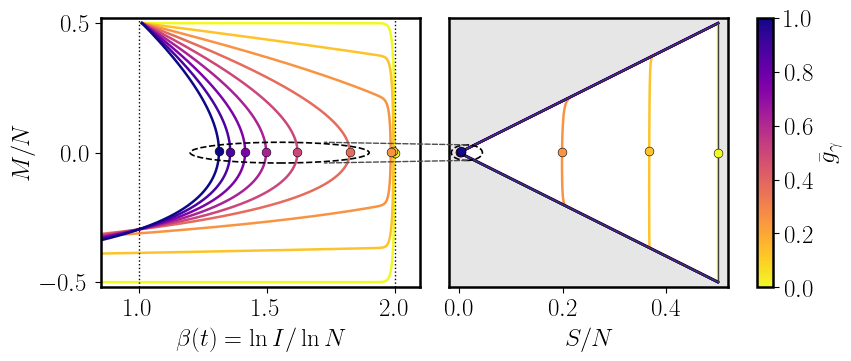

(outfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/code/../data/beta_dicke_triangle_gamma_scan.pdf", logN = 115.12925464970229, scan = :gamma, parameter_sets = [(g_xi = 0.0, bar_g_gamma = 0.0), (g_xi = 0.0, bar_g_gamma = 0.125), (g_xi = 0.0, bar_g_gamma = 0.25), (g_xi = 0.0, bar_g_gamma = 0.375), (g_xi = 0.0, bar_g_gamma = 0.5), (g_xi = 0.0, bar_g_gamma = 0.625), (g_xi = 0.0, bar_g_gamma = 0.75), (g_xi = 0.0, bar_g_gamma = 0.875), (g_xi = 0.0, bar_g_gamma = 1.0)], summaries = NamedTuple[(g_xi = 0.0, bar_g_gamma = 0.0, peak_tau = 115.13069378337458, peak_Ifrak = 0.2499998705559422, peak_n_t = 0.4996402166439468, peak_n_delta = 0.5003597833560641), (g_xi = 0.0, bar_g_gamma = 0.125, peak_tau = 132.90399463618303, peak_Ifrak = 0.13477706122773864, peak_n_t = 0.3723332441846764, peak_n_delta = 0.3619796602445995), (g_xi = 0.0, bar_g_gamma = 0.25, peak_tau = 168.0908129237269, peak_Ifrak = 0.03952211213698001, peak_n_t = 0.20040798976014332, peak_n_d

In [102]:
using DifferentialEquations

_plot_cache_dir = mktempdir()
ENV["MPLCONFIGDIR"] = get(ENV, "MPLCONFIGDIR", _plot_cache_dir)
ENV["XDG_CACHE_HOME"] = get(ENV, "XDG_CACHE_HOME", _plot_cache_dir)

using PyPlot
using Printf

"""
    meanfield_bar_gamma!(du, u, p, tau)

Mean-field equations in rescaled time tau = N Gamma t, using
u = [log(Ifrak), mfrak]. The spontaneous-emission parameter is supplied as
bar_g_gamma = g_gamma log(N), so g_gamma = bar_g_gamma / log(N).
"""
function meanfield_bar_gamma!(du, u, p, tau)
    logI, m = u
    g_xi, bar_g_gamma, logN = p
    g_gamma = bar_g_gamma / logN

    du[1] = 2.0 * m - g_xi - g_gamma
    du[2] = -exp(logI) - g_gamma * (m + 0.5)

    return nothing
end

function solve_trajectory(;
    logN = 10.0 * log(10.0),
    g_xi = 0.2,
    bar_g_gamma = 0.05,
    tau_factor = 50.0,
    savepoints = 80000,
    reltol = 1e-15,
    abstol = 1e-15,
)
    u0 = [-logN, 0.5]
    tau_end = tau_factor * logN
    p = (g_xi, bar_g_gamma, logN)

    prob = ODEProblem(meanfield_bar_gamma!, u0, (0.0, tau_end), p)
    sol = solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = reltol,
        abstol = abstol,
        saveat = range(0.0, tau_end, savepoints),
    )

    return sol
end

function trajectory_coordinates(sol; logN)
    tau = collect(sol.t)
    logI = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]
    Ifrak = exp.(logI)

    s = sqrt.(max.(Ifrak .+ m.^2, 0.0))
    n_t = s .+ m
    n_delta = s .- m
    depletion = 0.5 .- m
    beta = (log(4.0) .+ logI .+ 2.0 * logN) ./ logN

    peak_index = argmax(logI)

    return (
        tau = tau,
        logI = logI,
        Ifrak = Ifrak,
        s = s,
        m = m,
        n_t = n_t,
        n_delta = n_delta,
        depletion = depletion,
        beta = beta,
        peak_index = peak_index,
        peak_tau = tau[peak_index],
        peak_Ifrak = Ifrak[peak_index],
        peak_n_t = n_t[peak_index],
        peak_n_delta = n_delta[peak_index],
    )
end

function parameter_sets_for_scan(;
    scan = :gamma,
    values = scan == :gamma ? range(0.0, 0.5, length = 9) : range(0.0, 0.8, length = 9),
    fixed_g_xi = 0.2,
    fixed_bar_g_gamma = 0.0,
)
    if scan == :gamma
        return [(g_xi = fixed_g_xi, bar_g_gamma = value) for value in values]
    elseif scan == :xi
        return [(g_xi = value, bar_g_gamma = fixed_bar_g_gamma) for value in values]
    else
        error("scan must be :gamma or :xi")
    end
end

function add_dicke_triangle!(ax)
    ax.set_facecolor("0.90")
    ax.fill(
        [0.0, 0.5, 0.5],
        [0.0, -0.5, 0.5],
        color = "white",
        zorder = -10,
    )

    ax.plot([0.0, 0.5], [0.0, 0.5], color = "0.25", linewidth = 1.0)
    ax.plot([0.0, 0.5], [0.0, -0.5], color = "0.25", linewidth = 1.0)
    ax.plot([0.5, 0.5], [-0.5, 0.5], color = "0.25", linewidth = 1.0)

    ax.set_xlim(-0.02, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_aspect(0.5, adjustable = "box")
    ax.set_xlabel(L"S/N")
    #ax.set_ylabel(L"M/N")

    return ax
end

function colorbar_label(scan)
    scan == :gamma && return L"\bar g_\gamma"
    scan == :xi && return L"g_\xi"
    error("scan must be :gamma or :xi")
end

function scan_value(params, scan)
    scan == :gamma && return params.bar_g_gamma
    scan == :xi && return params.g_xi
    error("scan must be :gamma or :xi")
end

function plot_beta_and_dicke_triangle(;
    outfile = joinpath(@__DIR__, "..", "data", "beta_dicke_triangle_gamma_scan.pdf"),
    logN = 10.0 * log(10.0),
    scan = :gamma,
    parameter_sets = parameter_sets_for_scan(scan = scan),
    tau_factor = 50.0,
    cmap_name = "viridis",
)
    mkpath(dirname(outfile))

    scan_values = [scan_value(params, scan) for params in parameter_sets]
    norm = matplotlib.colors.Normalize(vmin = minimum(scan_values), vmax = maximum(scan_values))
    cmap = get_cmap(cmap_name)

    w, h = latex_plot_setup(font_size_pt = 18)
    fig = figure(figsize = (8.4, 3.5), constrained_layout = true)
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios = [1.36, 1.36, 0.07],
        wspace = 0.02,
    )
    ax_beta = fig.add_subplot(gs[1, 1])
    ax_triangle = fig.add_subplot(gs[1, 2], sharey = ax_beta)
    cax = fig.add_subplot(gs[1, 3])

    summaries = NamedTuple[]

    for params in parameter_sets
        sol = solve_trajectory(;
            logN = logN,
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            tau_factor = tau_factor,
        )
        coords = trajectory_coordinates(sol; logN = logN)
        color = cmap(norm(scan_value(params, scan)))

        ax_beta.plot(coords.beta, coords.m, color = color, linewidth = 1.8)
        ax_triangle.plot(coords.s, coords.m, color = color, linewidth = 1.8)

        ax_beta.scatter(
            [coords.beta[coords.peak_index]],
            [coords.m[coords.peak_index]],
            color = color,
            edgecolors = "k",
            linewidths = 0.4,
            s = 40,
            zorder = 4,
        )

        ax_triangle.scatter(
            [coords.s[coords.peak_index]],
            [coords.m[coords.peak_index]],
            color = color,
            edgecolors = "k",
            linewidths = 0.4,
            s = 40,
            zorder = 4,
        )

        push!(summaries, (
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            peak_tau = coords.peak_tau,
            peak_Ifrak = coords.peak_Ifrak,
            peak_n_t = coords.peak_n_t,
            peak_n_delta = coords.peak_n_delta,
        ))
    end

    ax_beta.axvline(2.0, color = "k", linestyle = "dotted", linewidth = 1.0)
    ax_beta.axvline(1.0, color = "k", linestyle = "dotted", linewidth = 1.0)
    ax_beta.set_xlim(left = 0.85, right = 2.1)
    ax_beta.set_ylim(-0.5,0.5)
    ax_beta.set_yticks([-0.5, 0.0, 0.5])
    ax_triangle.set_yticks([-0.5, 0.0, 0.5])
    
    ax_beta.set_ylabel(L"M/N")
    ax_beta.set_xlabel(L"\beta(t)=\ln I/\ln N")

    add_dicke_triangle!(ax_triangle)

    sm = matplotlib.cm.ScalarMappable(norm = norm, cmap = cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax = cax)
    cbar.set_label(colorbar_label(scan))

if scan == :gamma
    patches = pyimport("matplotlib.patches")
# --------------------------------------------------
# adjustable conceptual zoom parameters
# --------------------------------------------------

circle_center = (0.015, 0.0)
circle_radius = 0.03

ellipse_center = (1.55, 0.0)
ellipse_width = 0.7
ellipse_height = 0.08

# connection anchor points relative to ellipse
ellipse_dx = ellipse_width / 2
ellipse_dy = ellipse_height / 2

# --------------------------------------------------
# circle
# --------------------------------------------------

circle = patches.Circle(
    circle_center,
    circle_radius,
    fill = false,
    edgecolor = "black",
    linestyle = "--",
    linewidth = 1.2,
    zorder = 10,
)

ax_triangle.add_patch(circle)

# --------------------------------------------------
# ellipse
# --------------------------------------------------

ellipse = patches.Ellipse(
    ellipse_center,
    ellipse_width,
    ellipse_height,
    fill = false,
    edgecolor = "black",
    linestyle = "--",
    linewidth = 1.2,
    zorder = 10,
)

ax_beta.add_patch(ellipse)

# --------------------------------------------------
# connection lines
# --------------------------------------------------

con1 = patches.ConnectionPatch(
    xyA = (
        circle_center[1],
        circle_center[2] + 1.0 * circle_radius,
    ),
    coordsA = ax_triangle.transData,

    xyB = (
        ellipse_center[1] + ellipse_dx/2,
        ellipse_center[2] + ellipse_dy,
    ),
    coordsB = ax_beta.transData,

    color = "0.3",
    linewidth = 1.0,
    linestyle = "--",
)

con2 = patches.ConnectionPatch(
    xyA = (
        circle_center[1],
        circle_center[2] - 1.0 * circle_radius,
    ),
    coordsA = ax_triangle.transData,

    xyB = (
        ellipse_center[1] + ellipse_dx/2,
        ellipse_center[2] - ellipse_dy,
    ),
    coordsB = ax_beta.transData,

    color = "0.3",
    linewidth = 1.0,
    linestyle = "--",
)

fig.add_artist(con1)
fig.add_artist(con2)

end
ax_triangle.tick_params(axis = "y", left = false, labelleft = false)


    fig.savefig(outfile, bbox_inches = "tight")

    return (
        outfile = outfile,
        logN = logN,
        scan = scan,
        parameter_sets = parameter_sets,
        summaries = summaries,
    )
end

Nf = 50.0

gamma_result = plot_beta_and_dicke_triangle(;
    outfile = joinpath(@__DIR__, "..", "data", "beta_dicke_triangle_gamma_scan.pdf"),
    logN = Nf * log(10.0),
    scan = :gamma,
    parameter_sets = parameter_sets_for_scan(
        scan = :gamma,
        values = range(0.0, 1.0, length = 9),
        fixed_g_xi = 0.0,
    ),
    cmap_name = "plasma_r"
)

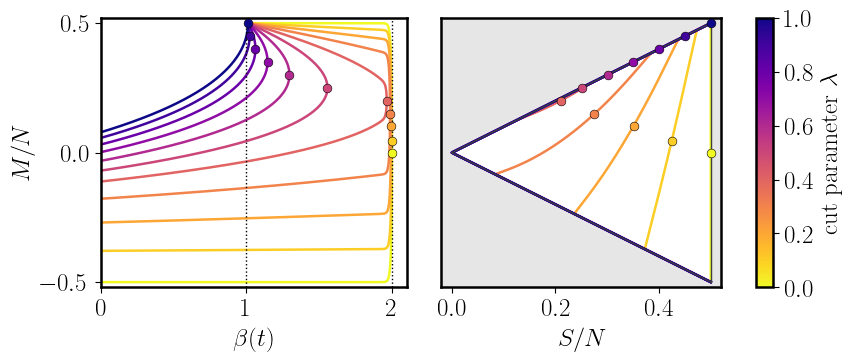

(outfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/code/../data/beta_dicke_triangle_phase_cut.pdf", csv_outfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/code/../data/beta_dicke_triangle_phase_cut.csv", logN = 115.12925464970229, parameter_sets = [(lambda = 0.0, g_xi = 0.0, bar_g_gamma = 0.0), (lambda = 0.1, g_xi = 0.1, bar_g_gamma = 0.025), (lambda = 0.2, g_xi = 0.2, bar_g_gamma = 0.05), (lambda = 0.3, g_xi = 0.3, bar_g_gamma = 0.075), (lambda = 0.4, g_xi = 0.4, bar_g_gamma = 0.1), (lambda = 0.5, g_xi = 0.5, bar_g_gamma = 0.125), (lambda = 0.6, g_xi = 0.6, bar_g_gamma = 0.15), (lambda = 0.7, g_xi = 0.7, bar_g_gamma = 0.175), (lambda = 0.8, g_xi = 0.8, bar_g_gamma = 0.2), (lambda = 0.9, g_xi = 0.9, bar_g_gamma = 0.225), (lambda = 1.0, g_xi = 1.0, bar_g_gamma = 0.25)], summaries = NamedTuple[(lambda = 0.0, g_xi = 0.0, bar_g_gamma = 0.0, peak_tau = 115.13069378337458, peak_Ifrak = 0.2499998705559422, peak

In [99]:
using DifferentialEquations

_plot_cache_dir = mktempdir()
ENV["MPLCONFIGDIR"] = get(ENV, "MPLCONFIGDIR", _plot_cache_dir)
ENV["XDG_CACHE_HOME"] = get(ENV, "XDG_CACHE_HOME", _plot_cache_dir)

include("PlotSetup.jl")

using PyPlot
using Printf

"""
    meanfield_bar_gamma!(du, u, p, tau)

Mean-field equations in rescaled time tau = N Gamma t, using
u = [log(Ifrak), mfrak]. The spontaneous-emission parameter is supplied as
bar_g_gamma = g_gamma log(N), so g_gamma = bar_g_gamma / log(N).
"""
function meanfield_bar_gamma!(du, u, p, tau)
    logI, m = u
    g_xi, bar_g_gamma, logN = p
    g_gamma = bar_g_gamma / logN

    du[1] = 2.0 * m - g_xi - g_gamma
    du[2] = -exp(logI) - g_gamma * (m + 0.5)

    return nothing
end

function solve_trajectory(;
    logN = 10.0 * log(10.0),
    g_xi = 0.2,
    bar_g_gamma = 0.05,
    tau_factor = 50.0,
    savepoints = 80000,
    reltol = 1e-15,
    abstol = 1e-15,
)
    u0 = [-logN, 0.5]
    tau_end = tau_factor * logN
    p = (g_xi, bar_g_gamma, logN)

    prob = ODEProblem(meanfield_bar_gamma!, u0, (0.0, tau_end), p)
    sol = solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = reltol,
        abstol = abstol,
        saveat = range(0.0, tau_end, savepoints),
    )

    return sol
end

function trajectory_coordinates(sol; logN)
    tau = collect(sol.t)
    logI = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]
    Ifrak = exp.(logI)

    s = sqrt.(max.(Ifrak .+ m.^2, 0.0))
    n_t = s .+ m
    n_delta = s .- m
    depletion = 0.5 .- m
    beta = (log(4.0) .+ logI .+ 2.0 * logN) ./ logN

    peak_index = argmax(logI)

    return (
        tau = tau,
        logI = logI,
        Ifrak = Ifrak,
        s = s,
        m = m,
        n_t = n_t,
        n_delta = n_delta,
        depletion = depletion,
        beta = beta,
        peak_index = peak_index,
        peak_tau = tau[peak_index],
        peak_Ifrak = Ifrak[peak_index],
        peak_beta = beta[peak_index],
        peak_m = m[peak_index],
        peak_s = s[peak_index],
        peak_n_t = n_t[peak_index],
        peak_n_delta = n_delta[peak_index],
    )
end

"""
    parameter_sets_for_cut(; lambda_values, g_xi_start, g_xi_stop,
                            bar_g_gamma_start, bar_g_gamma_stop)

Build a one-dimensional cut through the (bar_g_gamma, g_xi) phase diagram.
The cut parameter lambda runs from 0 to 1 by default. Both parameters are
linearly interpolated between their start and stop values.
"""
function parameter_sets_for_cut(;
    lambda_values = range(0.0, 1.0, length = 11),
    g_xi_start = 0.0,
    g_xi_stop = 1.0,
    bar_g_gamma_start = 0.0,
    bar_g_gamma_stop = 1.0,
)
    return [
        (
            lambda = lambda,
            g_xi = (1.0 - lambda) * g_xi_start + lambda * g_xi_stop,
            bar_g_gamma = (1.0 - lambda) * bar_g_gamma_start + lambda * bar_g_gamma_stop,
        )
        for lambda in lambda_values
    ]
end

function add_dicke_triangle!(ax)
    ax.set_facecolor("0.90")
    ax.fill(
        [0.0, 0.5, 0.5],
        [0.0, -0.5, 0.5],
        color = "white",
        zorder = -10,
    )

    ax.plot([0.0, 0.5], [0.0, 0.5], color = "0.25", linewidth = 1.0)
    ax.plot([0.0, 0.5], [0.0, -0.5], color = "0.25", linewidth = 1.0)
    ax.plot([0.5, 0.5], [-0.5, 0.5], color = "0.25", linewidth = 1.0)

    ax.set_xlim(-0.02, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_aspect(0.5, adjustable = "box")
    ax.set_xlabel(L"S/N")

    return ax
end

function summarize_cut(;
    logN = 10.0 * log(10.0),
    parameter_sets = parameter_sets_for_cut(),
    tau_factor = 50.0,
    savepoints = 80000,
    reltol = 1e-15,
    abstol = 1e-15,
)
    summaries = NamedTuple[]

    for params in parameter_sets
        sol = solve_trajectory(;
            logN = logN,
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            tau_factor = tau_factor,
            savepoints = savepoints,
            reltol = reltol,
            abstol = abstol,
        )
        coords = trajectory_coordinates(sol; logN = logN)

        push!(summaries, (
            lambda = params.lambda,
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            peak_tau = coords.peak_tau,
            peak_Ifrak = coords.peak_Ifrak,
            peak_beta = coords.peak_beta,
            peak_m = coords.peak_m,
            peak_s = coords.peak_s,
            peak_n_t = coords.peak_n_t,
            peak_n_delta = coords.peak_n_delta,
        ))
    end

    return summaries
end

function write_cut_summary_csv(outfile, summaries)
    mkpath(dirname(outfile))
    open(outfile, "w") do io
        println(io, "lambda,g_xi,bar_g_gamma,peak_tau,peak_Ifrak,peak_beta,peak_m,peak_s,peak_n_t,peak_n_delta")
        for row in summaries
            @printf(
                io,
                "%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g\n",
                row.lambda,
                row.g_xi,
                row.bar_g_gamma,
                row.peak_tau,
                row.peak_Ifrak,
                row.peak_beta,
                row.peak_m,
                row.peak_s,
                row.peak_n_t,
                row.peak_n_delta,
            )
        end
    end

    return outfile
end

function plot_beta_and_dicke_triangle_cut(;
    outfile = joinpath(@__DIR__, "..", "data", "beta_dicke_triangle_phase_cut.pdf"),
    csv_outfile = replace(outfile, ".pdf" => ".csv"),
    logN = 10.0 * log(10.0),
    parameter_sets = parameter_sets_for_cut(),
    tau_factor = 50.0,
    savepoints = 80000,
    reltol = 1e-15,
    abstol = 1e-15,
    cmap_name = "plasma_r",
    colorbar_label = L"cut parameter $\lambda$",
)
    mkpath(dirname(outfile))

    lambda_values = [params.lambda for params in parameter_sets]
    norm = matplotlib.colors.Normalize(vmin = minimum(lambda_values), vmax = maximum(lambda_values))
    cmap = get_cmap(cmap_name)

    latex_plot_setup(font_size_pt = 18)
    fig = figure(figsize = (8.4, 3.5), constrained_layout = true)
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios = [1.25, 1.36, 0.07],
        wspace = 0.02,
    )
    ax_beta = fig.add_subplot(gs[1, 1])
    ax_triangle = fig.add_subplot(gs[1, 2], sharey = ax_beta)
    cax = fig.add_subplot(gs[1, 3])

    summaries = NamedTuple[]

    for params in parameter_sets
        sol = solve_trajectory(;
            logN = logN,
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            tau_factor = tau_factor,
            savepoints = savepoints,
            reltol = reltol,
            abstol = abstol,
        )
        coords = trajectory_coordinates(sol; logN = logN)
        color = cmap(norm(params.lambda))

        ax_beta.plot(coords.beta, coords.m, color = color, linewidth = 1.8)
        ax_triangle.plot(coords.s, coords.m, color = color, linewidth = 1.8)

        ax_beta.scatter(
            [coords.beta[coords.peak_index]],
            [coords.m[coords.peak_index]],
            color = color,
            edgecolors = "k",
            linewidths = 0.4,
            s = 40,
            zorder = 4,
        )

        ax_triangle.scatter(
            [coords.s[coords.peak_index]],
            [coords.m[coords.peak_index]],
            color = color,
            edgecolors = "k",
            linewidths = 0.4,
            s = 40,
            zorder = 4,
        )

        push!(summaries, (
            lambda = params.lambda,
            g_xi = params.g_xi,
            bar_g_gamma = params.bar_g_gamma,
            peak_tau = coords.peak_tau,
            peak_Ifrak = coords.peak_Ifrak,
            peak_beta = coords.peak_beta,
            peak_m = coords.peak_m,
            peak_s = coords.peak_s,
            peak_n_t = coords.peak_n_t,
            peak_n_delta = coords.peak_n_delta,
        ))
    end

    ax_beta.axvline(2.0, color = "k", linestyle = "dotted", linewidth = 1.0)
    ax_beta.axvline(1.0, color = "k", linestyle = "dotted", linewidth = 1.0)
    ax_beta.set_xlim(left = 0.0, right = 2.1)
    ax_beta.set_ylim(-0.5, 0.5)
    ax_beta.set_yticks([-0.5, 0.0, 0.5])
    ax_triangle.set_yticks([-0.5, 0.0, 0.5])

    ax_beta.set_ylabel(L"M/N")
    ax_beta.set_xlabel(L"\beta(t)")

    add_dicke_triangle!(ax_triangle)
    ax_triangle.tick_params(axis = "y", left = false, labelleft = false)

    sm = matplotlib.cm.ScalarMappable(norm = norm, cmap = cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax = cax)
    cbar.set_label(colorbar_label)

    fig.savefig(outfile, bbox_inches = "tight")


    return (
        outfile = outfile,
        csv_outfile = csv_outfile,
        logN = logN,
        parameter_sets = parameter_sets,
        summaries = summaries,
    )
end

Nf = 50.0

result = plot_beta_and_dicke_triangle_cut(;
    outfile = joinpath(@__DIR__, "..", "data", "beta_dicke_triangle_phase_cut.pdf"),
    logN = Nf * log(10.0),
    parameter_sets = parameter_sets_for_cut(
        lambda_values = range(0.0, 1.0, length = 11),
        g_xi_start = 0.0,
        g_xi_stop = 1.0,
        bar_g_gamma_start = 0.0,
        bar_g_gamma_stop = 0.25,
    ),
    cmap_name = "plasma_r",
)
